In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

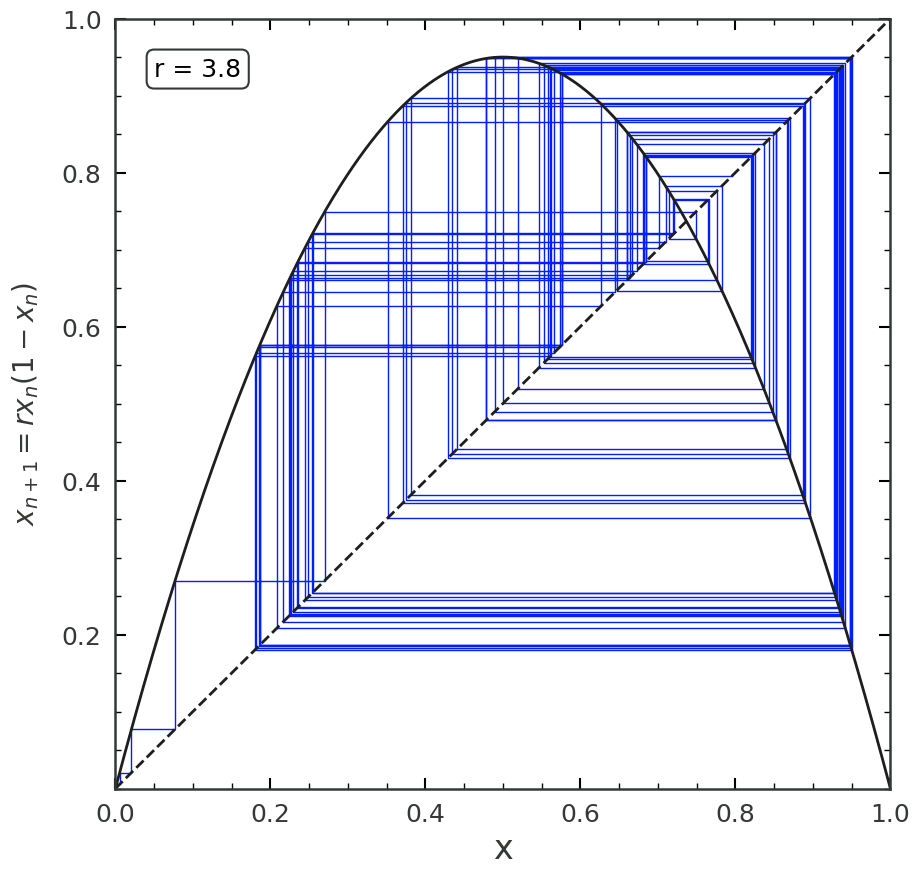

In [4]:
x0 = 0.0001
r = 3.8

x = np.linspace(0, 1, 1000)
y = r*x*(1-x)

fig, ax = plt.subplots(1, 1, figsize = (10,10))

x_map = [x0]
y_map = [0]

for _ in range(100):
    y_map.append(r*x_map[-1]*(1 - x_map[-1]))
    x_map.append(x_map[-1]) 
    x_map.append(y_map[-1])
    y_map.append(y_map[-1])

ax.plot(x_map,y_map, color='#001eff', lw = 1)

ax.plot(x,y, color='#1e1e1e', lw = 2)
ax.axline((0, 0), slope=1, color='#1e1e1e', linestyle='--', lw = 2)

ax.annotate(f'r = {r}', xy=(0.05, 0.95), xycoords='axes fraction', ha='left', va='top', fontsize=18, bbox=dict(boxstyle="round", fc="w", color = '#353935', lw = 1.5))

ax.set_xlim(0, 1)
ax.set_ylim(0,1)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.spines['top'].set_linewidth(1.8)
ax.spines['right'].set_linewidth(1.8)
ax.spines['bottom'].set_color('#353935')
ax.spines['left'].set_color('#353935')
ax.spines['top'].set_color('#353935')
ax.spines['right'].set_color('#353935')

ax.set_xlabel('x', fontsize = 24, color = '#353935')
ax.set_ylabel(r'$x_{{n+1}} = rx_{{n}} \left(1- x_{{n}}\right)$', fontsize = 20, color = '#353935', labelpad = 15)

ax.xaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

ax.tick_params(axis='both', which='major', labelsize=18, width=1.5, length=8, direction='in', top = True, right = True)
ax.tick_params(axis='both', which='minor', width=1, length=4, direction='in' , top = True, right = True)
ax.tick_params(axis='both', pad=10)


ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6, prune='lower'))

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')

plt.savefig('a2q1_a.pdf', dpi = 600)
plt.show()

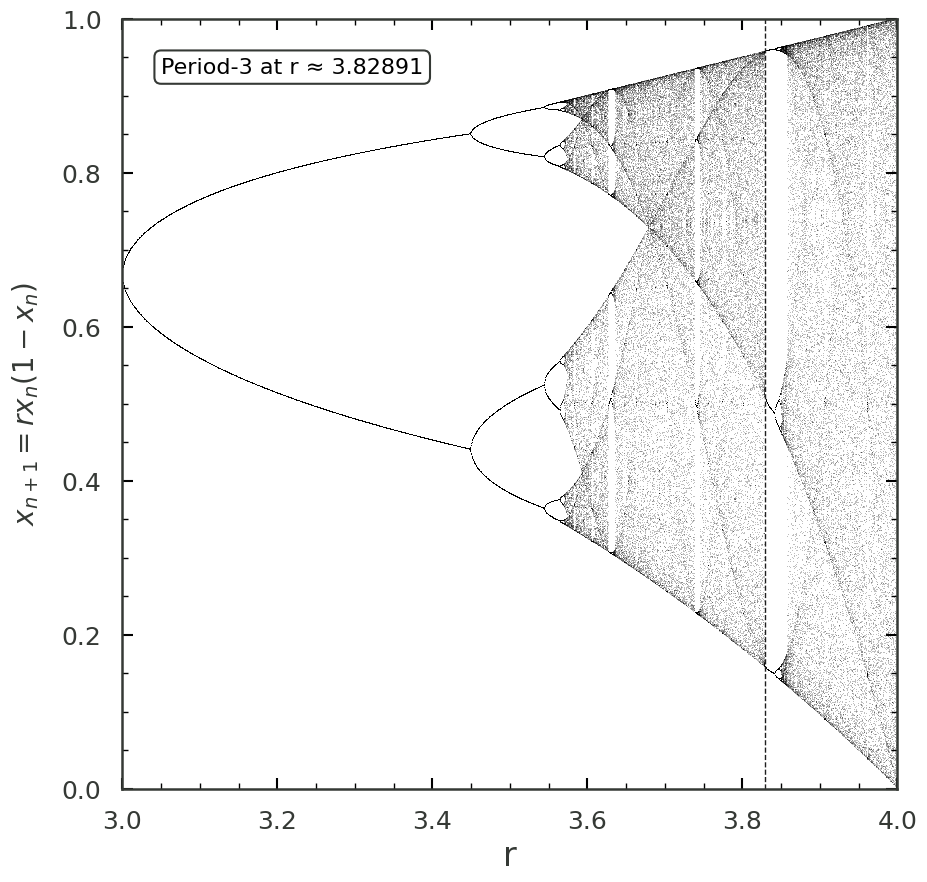

Estimated value of r for period-3 cycle: 3.8289144572286142


In [5]:
def logistic_map(x, r):
    return r * x * (1 - x)

def check_period(x, n, tolerance=1e-5):
    return np.allclose(x[-n:], x[-2*n:-n], atol=tolerance)

r_min, r_max = 3.0, 4.0
r_values = np.linspace(r_min, r_max, 2000)
n_iterations = 1000  
n_last = 100  
period = 3  
x_init = 1e-5  

fig, ax = plt.subplots(figsize=(10, 10))

r_period_3 = None

for r in r_values:
    x = x_init  
    trajectory = []

    for i in range(n_iterations):
        x = logistic_map(x, r) 
        trajectory.append(x)

        if i >= (n_iterations - n_last):
            ax.plot(r, x, ',k', alpha=0.25)

    if r_period_3 is None and check_period(trajectory, period):
        r_period_3 = r 

if r_period_3:
    ax.axvline(x=r_period_3, color='#1e1e1e', linestyle='--', lw = 1)

ax.set_xlim(r_min, r_max)
ax.set_ylim(0, 1)
ax.set_xlabel('r', fontsize=24, color='#353935')
ax.set_ylabel(r'$x_{n+1} = rx_{n} (1 - x_{n})$', fontsize=20, color='#353935', labelpad=15)

ax.annotate(f'Period-3 at r ≈ {r_period_3:.5f}', xy=(0.05, 0.95), xycoords='axes fraction', ha='left', va='top', fontsize=16, bbox=dict(boxstyle="round", fc="w", color = '#353935', lw = 1.5))
for side in ['bottom', 'left', 'top', 'right']:
    ax.spines[side].set_linewidth(1.8)
    ax.spines[side].set_color('#353935')

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')

ax.xaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax.tick_params(axis='both', which='major', labelsize=18, width=1.5, length=8, direction='in', top=True, right=True)
ax.tick_params(axis='both', which='minor', width=1, length=4, direction='in', top=True, right=True)
ax.tick_params(axis='both', pad=15)
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))

plt.savefig('a2q1_b.pdf', dpi = 600)
plt.show()

print(f"Estimated value of r for period-3 cycle: {r_period_3}")

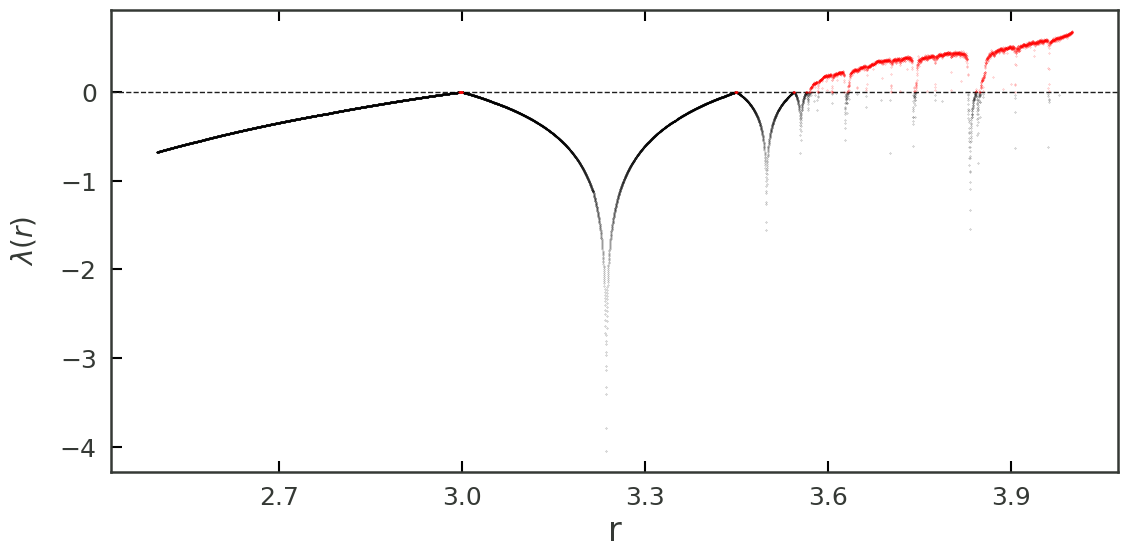

In [157]:
def logistic(r, x):
    return r * x * (1 - x)

n = 10000
r = np.linspace(2.5, 4.0, n)
iterations = 1000
last = 100
x = 1e-5 * np.ones(n)
lyapunov = np.zeros(n)

for i in range(iterations):
    x = logistic(r,x)
    lyapunov += np.log(abs(r-2*r*x))
    
fig, ax = plt.subplots(1, 1, figsize = (13,6))

ax.axhline(0, color='#1e1e1e', linestyle='--', lw = 1)
ax.plot(r[lyapunov < 0], lyapunov[lyapunov < 0] / iterations,'.k', alpha=.5, ms=.5)
ax.plot(r[lyapunov >= 0],lyapunov[lyapunov >= 0] / iterations,'.r', alpha=.5, ms=.5)

ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.spines['top'].set_linewidth(1.8)
ax.spines['right'].set_linewidth(1.8)
ax.spines['bottom'].set_color('#353935')
ax.spines['left'].set_color('#353935')
ax.spines['top'].set_color('#353935')
ax.spines['right'].set_color('#353935')

ax.set_xlabel('r', fontsize = 24, color = '#353935')
ax.set_ylabel('$\lambda (r)$', fontsize = 20, color = '#353935', labelpad = 15)

ax.xaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

ax.tick_params(axis='both', which='major', labelsize=18, width=1.5, length=8, direction='in', top = True)
ax.tick_params(axis='both', which='minor', width=0, length=0, direction='in' , top = True, right = True)
ax.tick_params(axis='both', pad=10)

ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6))

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')

plt.savefig('a2q1_c.pdf', dpi = 600)
plt.show()

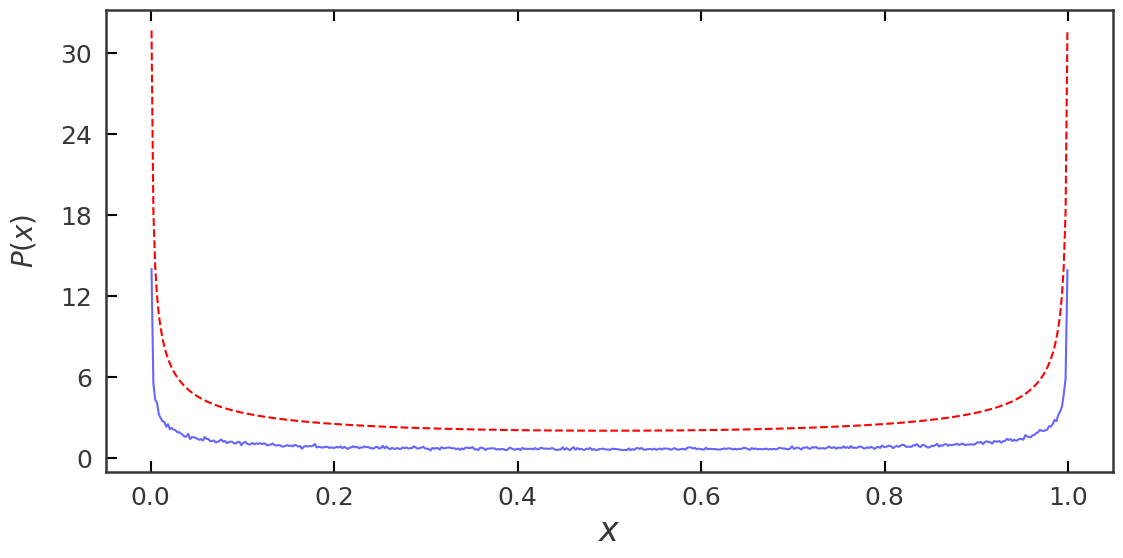

In [158]:
def logistic_map(x, r):
    return r * x * (1 - x)
r = 4
n_iterations = 1000000  
n_last = 100000
x = np.random.rand()  
trajectory = []

for _ in range(n_iterations):
    x = logistic_map(x, r)
    trajectory.append(x)

trajectory = np.array(trajectory[-n_last:])

hist, bins = np.histogram(trajectory, bins=500, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

def analytical_P(x):
    return np.where((x >= 0) & (x <= 1), 1 / np.sqrt(x * (1 - x)), 0)

analytical_density = analytical_P(bin_centers)


fig, ax = plt.subplots(1, 1, figsize = (13,6))

ax.plot(bin_centers, hist, label='Numerical Probability Density', color='blue', alpha=0.6)
ax.plot(bin_centers, analytical_density, label='Analytical Probability Density', color='red', linestyle='--')

ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.spines['top'].set_linewidth(1.8)
ax.spines['right'].set_linewidth(1.8)
ax.spines['bottom'].set_color('#353935')
ax.spines['left'].set_color('#353935')
ax.spines['top'].set_color('#353935')
ax.spines['right'].set_color('#353935')

ax.set_xlabel('$x$', fontsize = 24, color = '#353935')
ax.set_ylabel('$P(x)$', fontsize = 20, color = '#353935', labelpad = 15)

ax.xaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

ax.tick_params(axis='both', which='major', labelsize=18, width=1.5, length=8, direction='in', top = True)
ax.tick_params(axis='both', which='minor', width=0, length=0, direction='in' , top = True, right = True)
ax.tick_params(axis='both', pad=10)

ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6))

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')

plt.savefig('a2q1_d.pdf', dpi = 600)
plt.show()

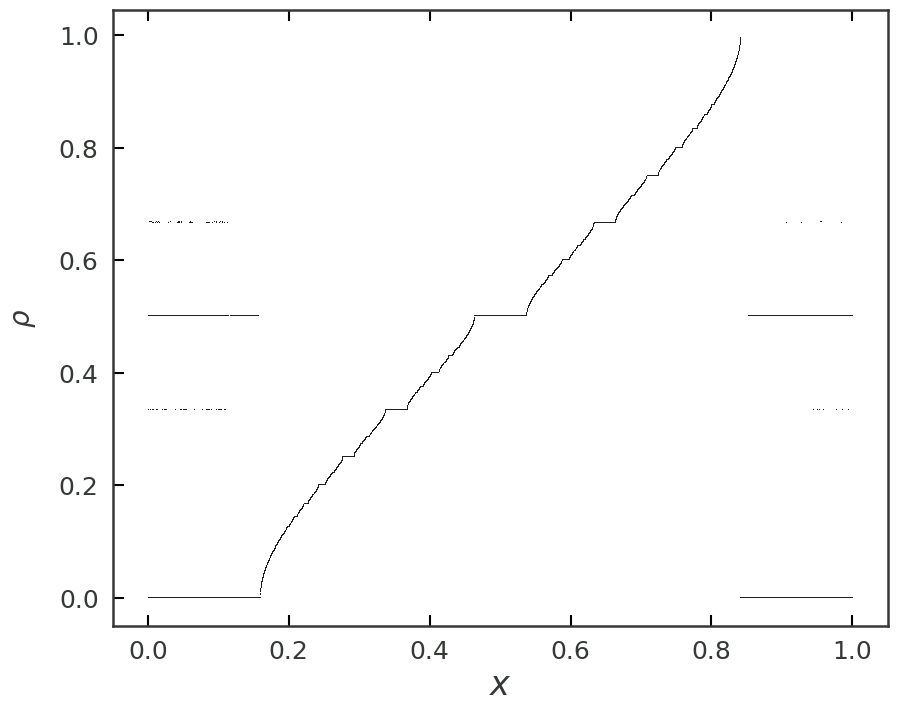

In [183]:
def sine_circle_map(theta, omega, K):
    return (theta + omega - (K / (2 * np.pi)) * np.sin(2 * np.pi * theta)) % 1

def compute_rotation_number(omega, K, num_iterations=5000, transient=10000):
    theta = 0.0
    for _ in range(transient):
        theta = sine_circle_map(theta, omega, K)
    
    rotation_sum = 0.0
    for _ in range(num_iterations):
        theta_next = sine_circle_map(theta, omega, K)
        rotation_sum += (theta_next - theta) % 1
        theta = theta_next
    rotation_number = rotation_sum / num_iterations
    return rotation_number

K = 1.0
omega_values = np.linspace(0, 1, 10000)
rotation_numbers = [compute_rotation_number(omega, K) for omega in omega_values]

fig, ax = plt.subplots(1, 1, figsize = (10,8))

ax.plot(omega_values, rotation_numbers, ',', markersize=3, color='#1e1e1e')

ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.spines['top'].set_linewidth(1.8)
ax.spines['right'].set_linewidth(1.8)
ax.spines['bottom'].set_color('#353935')
ax.spines['left'].set_color('#353935')
ax.spines['top'].set_color('#353935')
ax.spines['right'].set_color('#353935')

ax.set_xlabel('$x$', fontsize = 24, color = '#353935')
ax.set_ylabel(r'$ \rho $', fontsize = 20, color = '#353935', labelpad = 15)

ax.xaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))

ax.tick_params(axis='both', which='major', labelsize=18, width=1.5, length=8, direction='in', top = True)
ax.tick_params(axis='both', which='minor', width=0, length=0, direction='in' , top = True, right = True)
ax.tick_params(axis='both', pad=10)

ax.xaxis.set_major_locator(MaxNLocator(6))
ax.yaxis.set_major_locator(MaxNLocator(6))

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')

plt.savefig('a2q2_a.pdf', dpi = 600)
plt.show()

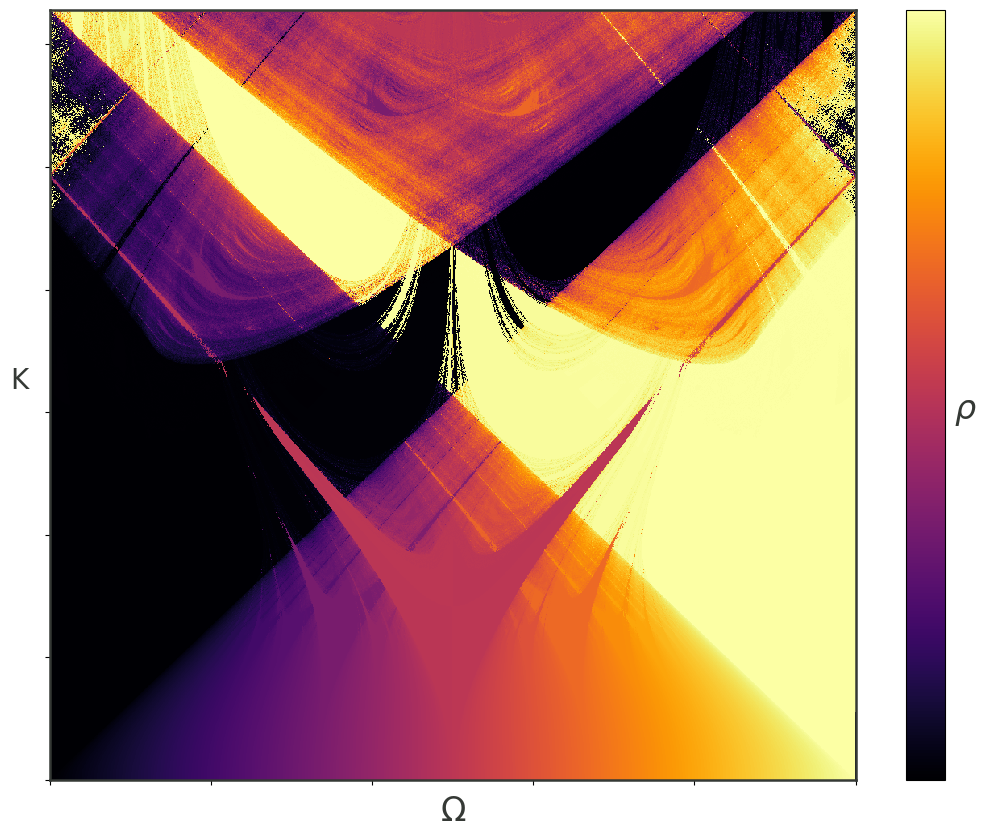

In [211]:
def cf(theta,Omega,K):
        twopi = 2.0*np.pi
        x = theta + Omega - (K/twopi)*np.sin(twopi*theta)
        return x

def circlemap(theta,Omega,K):
        x = cf(theta,Omega,K)
        return np.fmod(x,1.0) 
    
def winding(theta0,Omega,K,nit):
        theta = theta0
        for i in range(0,nit):
            theta = cf(theta,Omega,K)
        msum = (theta-theta0)/float(nit)
        return np.mod(msum,1.0)
    
def fillwinding(X,Y):
        nr= len(X)
        nc= len(X[0])
        WW = X*0.0 + 0.0
        theta0 = 0.5
        for i in range(0,nr):
            for j in range(0,nc):
                xij = X[i][j]
                yij = Y[i][j]   
                WW[i][j] = winding(theta0,xij,yij,200)
                        
        return WW
    
ngrid = 1000.0
xmax = 1.0
dx = xmax/ngrid
ymax = 2.0*np.pi
dy = ymax/ngrid
X,Y = np.meshgrid(np.arange(0.0,xmax+dx,dx),np.arange(0.0,ymax+dy,dy))
WW = fillwinding(X,Y)

fig,ax = plt.subplots(1,1,figsize=(13,10))
ax.set_xlim([0,xmax])
ax.set_ylim([0,ymax])

cc = ax.pcolormesh(X,Y,WW, cmap = 'inferno')
cbar = fig.colorbar(cc, ax=ax) 
cbar.set_label(r"$\rho$",fontweight='normal', fontsize=24, color = '#353935', rotation = 0,  labelpad = 15)
cbar.set_ticks([])

ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.spines['top'].set_linewidth(1.8)
ax.spines['right'].set_linewidth(1.8)
ax.spines['bottom'].set_color('#353935')
ax.spines['left'].set_color('#353935')
ax.spines['top'].set_color('#353935')
ax.spines['right'].set_color('#353935')

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_xlabel(r'$\Omega$', fontsize = 24, color = '#353935')
ax.set_ylabel('K', fontsize = 20, color = '#353935',rotation = 0,  labelpad = 15)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')

plt.savefig('a2q2_b.pdf', dpi = 400)
plt.show()

In [5]:
height, width = 8, 8
original_image = np.linspace(0, 255, height * width, dtype=np.uint8).reshape(height, width)

x_coords, y_coords = np.meshgrid(np.linspace(0, 1, width), np.linspace(0, 1, height))

def chaotic_map(x, y):
    x_new = (2 * x + y) % 1
    y_new = (x + y) % 1
    return x_new, y_new

iterations = 0
max_iterations = 100000
tolerance = 1e-1

images_at_intervals = {}
save_iterations = [1, 10, 100, 1000, 10000]
images_at_intervals[0] = original_image.copy()

while iterations < max_iterations:
    x_coords, y_coords = chaotic_map(x_coords, y_coords)
    x_pixels = (x_coords * (width - 1)).astype(int)
    y_pixels = (y_coords * (height - 1)).astype(int)
    evolved_image = original_image[y_pixels, x_pixels]
    
    if iterations in save_iterations:
        images_at_intervals[iterations] = evolved_image.copy()
    
    if np.allclose(original_image, evolved_image, atol=tolerance):
        print(f'Image returned to its original state after {iterations + 1} iterations')
        break
    
    iterations += 1

if iterations == max_iterations:
    print('Max iterations reached without returning to original image')

Max iterations reached without returning to original image


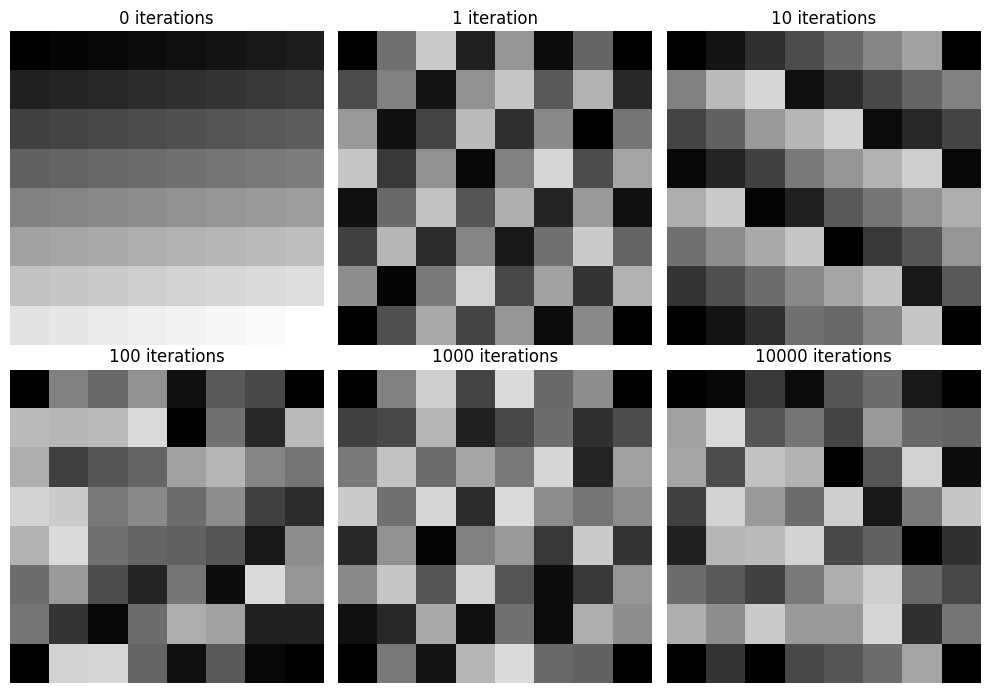

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
plot_titles = ['0 iterations', '1 iteration', '10 iterations', '100 iterations', '1000 iterations', '10000 iterations']
plot_positions = [0, 1, 10, 100, 1000, 10000]

for idx, ax in enumerate(axes.flat):
    iteration = plot_positions[idx]
    ax.imshow(images_at_intervals[iteration], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"{plot_titles[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Max iterations reached without returning to original image


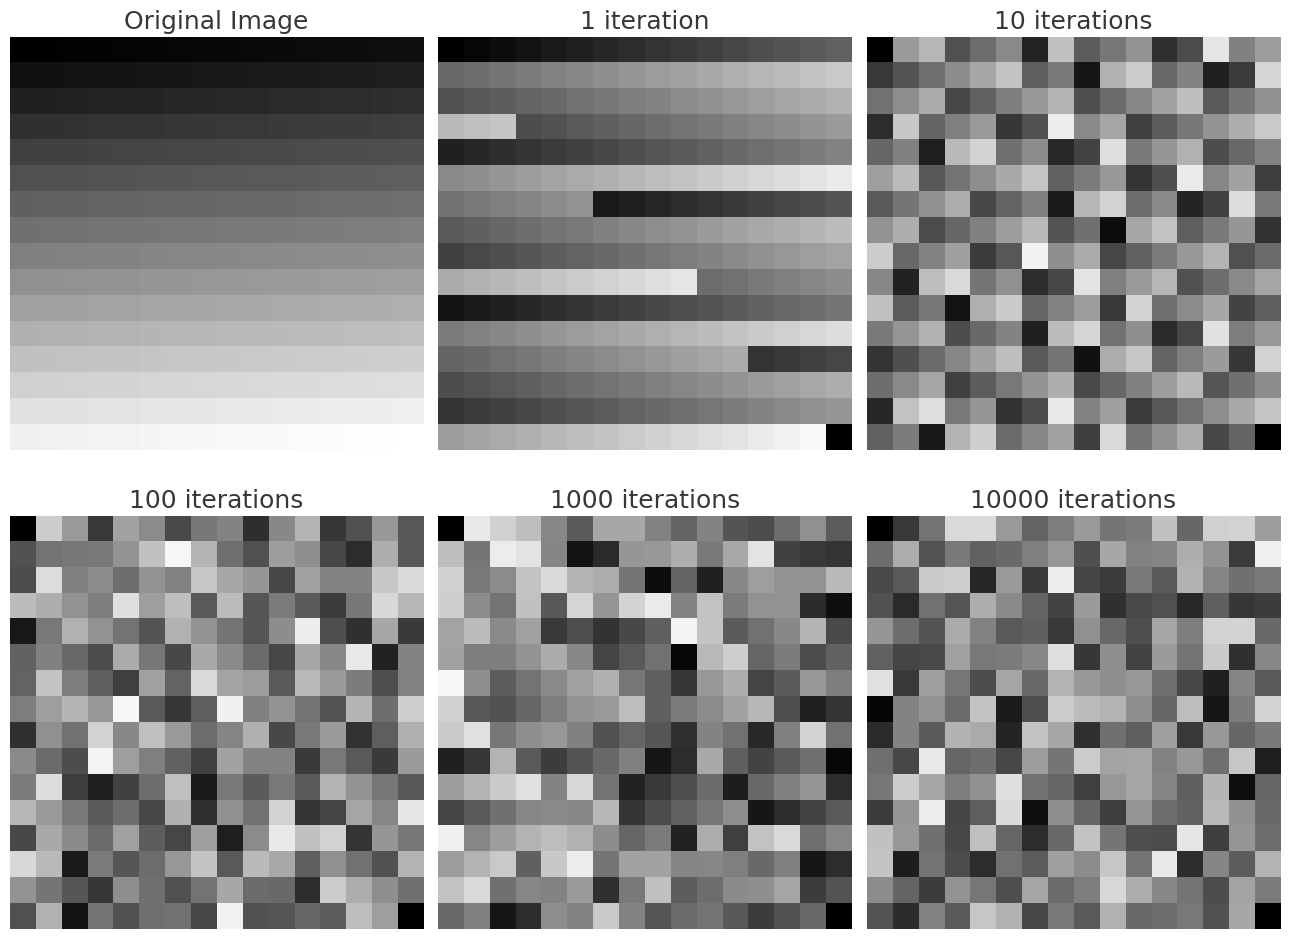

In [12]:
height, width = 16, 16
original_image = np.linspace(0, 255, height * width, dtype=np.uint8).reshape(height, width)

x_coords = original_image / 255.0
y_coords = original_image / 255.0

def chaotic_map(x, y):
    x_new = (2 * x + y) % 1
    y_new = (x + y) % 1
    return x_new, y_new

iterations = 0
max_iterations = 1000000 

tolerance = 1e-3

images_at_intervals = {}
save_iterations = [1, 10, 100, 1000, 10000]

images_at_intervals[0] = original_image.copy()

while iterations < max_iterations:
    x_coords, y_coords = chaotic_map(x_coords, y_coords)
    evolved_image = ((x_coords + y_coords) / 2.0 * 255).astype(np.uint8)
    if iterations in save_iterations:
        images_at_intervals[iterations] = evolved_image.copy()

    if np.allclose(original_image, evolved_image, atol=tolerance):
        print(f'Image returned to its original state after {iterations + 1} iterations')
        break
    
    iterations += 1

if iterations == max_iterations:
    print('Max iterations reached without returning to original image')

fig, axes = plt.subplots(2, 3, figsize=(13, 10))
plot_titles = ['Original Image', '1 iteration', '10 iterations', '100 iterations', '1000 iterations', '10000 iterations']
plot_positions = [0, 1, 10, 100, 1000, 10000]

for idx, ax in enumerate(axes.flat):
    iteration = plot_positions[idx]
    ax.imshow(images_at_intervals[iteration], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"{plot_titles[idx]}", fontweight='normal', fontsize=18, color='#353935')
    ax.axis('off')

plt.savefig('a2q3.pdf', dpi = 600)
plt.tight_layout()
plt.show()